## Problem Statement:

 Dataset
 https://www.kaggle.com/datasets/tarunpaparaju/apple-aapl-historical-stock-data?utm_source=chatgpt.com

Take out the dataset and then:
* Compute daily returns
  return = log(close today / close yesterday)
* Compute rolling volatility (e.g., 21-day standard deviation)
* Use it as the target variable for forecasting future volatility using any of the models (preferably LSTMs) that yield the best efficiency.
* You should focus on making the model and achieve higher accuracy.


In [ ]:
import pandas as pd
import numpy as np
df = pd.read_csv('/content/HistoricalQuotes.csv')
df

# Calculating Close/Last ratio

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date', ascending=True).reset_index(drop=True)
df.index = df['Date']
df.drop('Date', axis=1, inplace=True)
df[[' Close/Last', ' Open', ' High', ' Low']] = df[[' Close/Last', ' Open', ' High', ' Low']].applymap(lambda x: float(x.replace('$', '').strip()))
df

# Log Returns

In [ ]:
df['Log_Return'] = np.log(df[' Close/Last']/df[' Close/Last'].shift(1))
df = df.dropna()
df

,Close/Last,Volume,Open,High,Low,Log_Return
Date,,,,,,
2010-03-02,29.8357,141486282,29.9900,30.1186,29.6771,-0.000670
2010-03-03,29.9043,92846488,29.8486,29.9814,29.7057,0.002297
2010-03-04,30.1014,89591907,29.8971,30.1314,29.8043,0.006569
2010-03-05,31.2786,224647427,30.7057,31.3857,30.6614,0.038362
2010-03-08,31.2971,107326832,31.4300,31.4414,31.1786,0.000591
...,...,...,...,...,...,...
2020-02-24,298.1800,55548830,297.2600,304.1800,289.2300,-0.048666
2020-02-25,288.0800,57668360,300.9500,302.5300,286.1300,-0.034459
2020-02-26,292.6500,49678430,286.5300,297.8800,286.5000,0.015739


# Rolling and Target Volatility

In [ ]:
df['Squared_Log_Return'] = df['Log_Return']**2
df['Volume_Change'] = df[' Volume'].pct_change()
df['Rolling_Vol'] = df['Log_Return'].rolling(window=21).std()
df['Target_Vol'] = df["Rolling_Vol"].shift(-1)
df = df.dropna()
df

/tmp/ipython-input-2662394141.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Squared_Log_Return'] = df['Log_Return']**2
/tmp/ipython-input-2662394141.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Volume_Change'] = df[' Volume'].pct_change()
/tmp/ipython-input-2662394141.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pan

,Close/Last,Volume,Open,High,Low,Log_Return,Squared_Log_Return,Volume_Change,Rolling_Vol,Target_Vol
Date,,,,,,,,,,
2010-04-28,37.3714,189375537,37.6071,37.7143,36.6300,-0.001682,0.000003,0.070186,0.016593,0.017109
2010-04-29,38.3771,139522502,37.5743,38.5714,37.4300,0.026555,0.000705,-0.263250,0.017109,0.018619
2010-04-30,37.2986,135421971,38.4728,38.6528,37.2857,-0.028505,0.000813,-0.029390,0.018619,0.018899
2010-05-03,38.0500,113343684,37.6914,38.2686,37.5543,0.019945,0.000398,-0.163033,0.018899,0.020333
2010-05-04,36.9543,180620564,37.5557,37.6128,36.6786,-0.029219,0.000854,0.593565,0.020333,0.020571
...,...,...,...,...,...,...,...,...,...,...
2020-02-20,320.3000,25141490,322.6300,324.6500,318.2100,-0.010312,0.000106,0.070033,0.018751,0.019416
2020-02-21,313.0500,32426420,318.6200,320.4500,310.5000,-0.022895,0.000524,0.289757,0.019416,0.021993
2020-02-24,298.1800,55548830,297.2600,304.1800,289.2300,-0.048666,0.002368,0.713073,0.021993,0.023022


# Training and Validation Split

In [ ]:
train_size = int(len(df) * 0.7) # training and validation split ---> 0.7 and 0.3
train_df = df.iloc[:train_size]
test_df = df.iloc[train_size:]

print(f"Training on {len(train_df)} days, Testing on {len(test_df)} days.")

Training on 1732 days, Testing on 743 days.


In [ ]:
from sklearn.preprocessing import MinMaxScaler

feature_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler = MinMaxScaler(feature_range=(0, 1))

feature_cols = ['Log_Return', 'Squared_Log_Return', 'Volume_Change', 'Rolling_Vol']
target_col = ['Target_Vol']

train_X_scaled = feature_scaler.fit_transform(train_df[feature_cols])
train_y_scaled = target_scaler.fit_transform(train_df[target_col])

test_X_scaled = feature_scaler.transform(test_df[feature_cols])
test_y_scaled = target_scaler.transform(test_df[target_col])

In [ ]:
def create_dataset(X, y, time_steps=1):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        v = X[i:(i + time_steps)]
        Xs.append(v)
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

time_steps = 21

X_train, y_train = create_dataset(train_X_scaled, train_y_scaled, time_steps)
X_test, y_test = create_dataset(test_X_scaled, test_y_scaled, time_steps)

print(f"X_train Shape: {X_train.shape}")
print(f"y_train Shape: {y_train.shape}")

X_train Shape: (1711, 21, 4)
y_train Shape: (1711, 1)


# Training with LSTM NNs

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])

#  Compile
model.compile(optimizer='adam', loss='mse')

# Train (Fit)
# EarlyStopping will stop training if validation loss stops improving for 10 epochs
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[EarlyStopping(monitor='val_loss', patience=10,restore_best_weights=True)],
    verbose=1
)
# restore_best_weights true : It will consider the weights at which the loss is minimum and stop

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - loss: 0.0430 - val_loss: 0.0099
Epoch 2/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0124 - val_loss: 0.0067
Epoch 3/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0085 - val_loss: 0.0063
Epoch 4/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0066 - val_loss: 0.0043
Epoch 5/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0065 - val_loss: 0.0043
Epoch 6/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0063 - val_loss: 0.0038
Epoch 7/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.0063 - val_loss: 0.0039
Epoch 8/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0057 - val_loss: 0.0038
Epoch 9/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0057 - val_loss: 0.0034
Epoch 10/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0053 - val_loss: 0.0035
Epoch 11/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0049 - val_loss: 0.0041
Epoch 12/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step

# Comparing Actual and Predicted Volatility

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


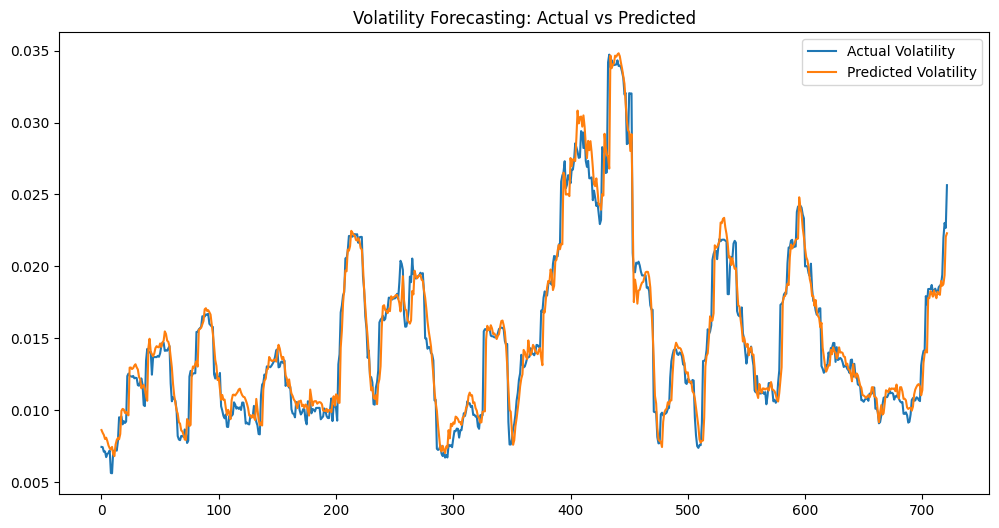

In [ ]:
import matplotlib.pyplot as plt

# Make predictions
preds = model.predict(X_test)

# Inverse transform to get real "Volatility %" back (instead of 0-1)
real_preds = target_scaler.inverse_transform(preds)
real_y = target_scaler.inverse_transform(y_test)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(real_y, label='Actual Volatility')
plt.plot(real_preds, label='Predicted Volatility')
plt.title('Volatility Forecasting: Actual vs Predicted')
plt.legend()
plt.show()

# Evaluating Accuracy

In [ ]:
# Metrics
import math
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse = math.sqrt(mean_squared_error(real_y, real_preds))
mae = mean_absolute_error(real_y, real_preds)
r2 = r2_score(real_y, real_preds)

print(f"Root Mean-Squared Error: {rmse}", )
print(f"Mean Absolute Error: {mae:.5f}", )
print(f"R-squared score:{r2:.4f}",)


Root Mean-Squared Error: 0.0013104785067662695
Mean Absolute Error: 0.00090
R-squared score:0.9511


# Comparison with standard GARCH model

In [ ]:
!pip install arch

from arch import arch_model

garch_returns = df['Log_Return'] * 100

cutoff_date = df.iloc[train_size].name  # the date index of the split

# fitting on full data on GARCH(1,1) but last_obs forces the model to learn from training part only
print("Fitting GARCH Model...")
gmodel = arch_model(garch_returns, vol='Garch', p=1, q=1, mean='Zero')
garch_fit = gmodel.fit(last_obs=cutoff_date, disp='off')
print(garch_fit.summary())

# forecasting on test set
# horizon=1 : predicting 1 day ahead
forecasts = garch_fit.forecast(start=cutoff_date, horizon=1, reindex=False)

# extracting variance
predicted_variance = forecasts.variance['h.1']

garch_prediction = np.sqrt(predicted_variance) / 100 # unscaling

# taking last n pred to compare models
aligned_garch_preds = garch_prediction.values[-len(real_y):]

Fitting GARCH Model...
                       Zero Mean - GARCH Model Results                        
Dep. Variable:             Log_Return   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.001
Vol Model:                      GARCH   Log-Likelihood:               -3264.69
Distribution:                  Normal   AIC:                           6535.38
Method:            Maximum Likelihood   BIC:                           6551.76
                                        No. Observations:                 1732
Date:                Fri, Jan 16 2026   Df Residuals:                     1732
Time:                        10:20:50   Df Model:                            0
                             Volatility Model                             
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega          0.1818  8.281e-02      2.1

--- RESULTS ---
LSTM RMSE:  0.00131, LSTM R-squared:0.9511
GARCH RMSE: 0.00354, GARCH R-squared:0.6421
LSTM (Deep Learning) beat GARCH!


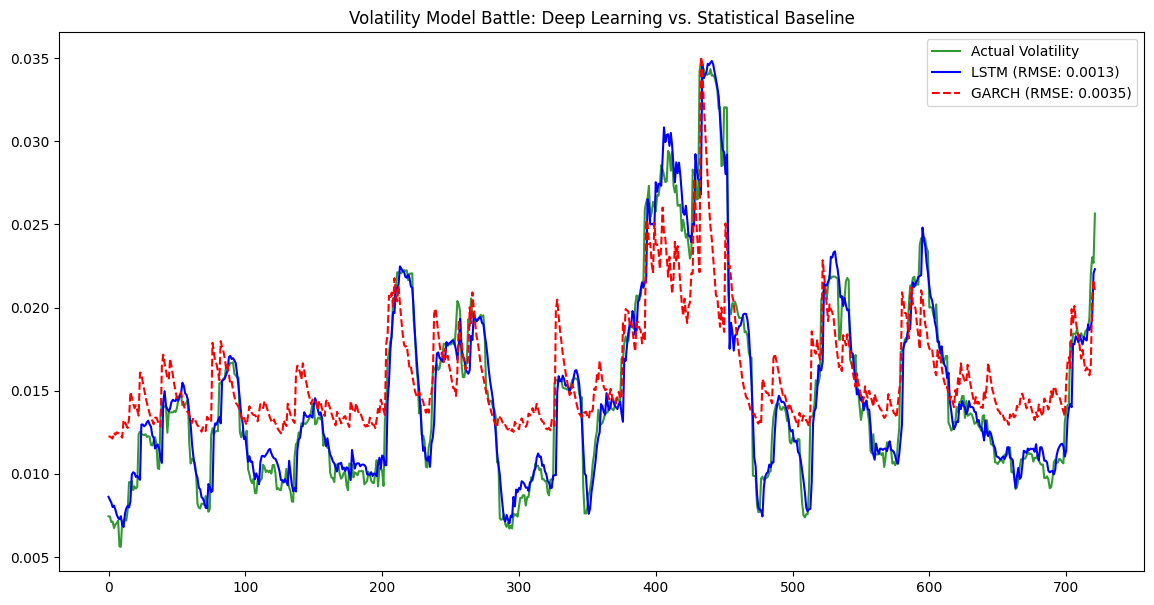

In [ ]:
lstm_rmse = rmse
garch_rmse = math.sqrt(mean_squared_error(real_y, aligned_garch_preds))
garch_r2= r2_score(real_y, aligned_garch_preds)
print(f"--- RESULTS ---")
print(f"LSTM RMSE:  {lstm_rmse:.5f}, LSTM R-squared:{r2:.4f}")
print(f"GARCH RMSE: {garch_rmse:.5f}, GARCH R-squared:{garch_r2:.4f}")

if lstm_rmse < garch_rmse:
    print("LSTM (Deep Learning) beat GARCH!")
else:
    print("GARCH (Statistics) beat LSTM.")

# plotting
plt.figure(figsize=(14, 7))
plt.plot(real_y, color='green', alpha=0.8, label='Actual Volatility')
plt.plot(real_preds, color='blue', linewidth=1.5, label=f'LSTM (RMSE: {lstm_rmse:.4f})')
plt.plot(aligned_garch_preds, color='red', linestyle='--', linewidth=1.5, label=f'GARCH (RMSE: {garch_rmse:.4f})')
plt.title('Volatility Model Battle: Deep Learning vs. Statistical Baseline')
plt.legend()
plt.show()